# **Penting**
- Jangan mengubah atau menambahkan cell text yang sudah disediakan, Anda hanya perlu mengerjakan cell code yang sudah disediakan.
- Pastikan seluruh kriteria memiliki output yang sesuai, karena jika tidak ada output dianggap tidak selesai.
- Misal, Anda menggunakan df = df.dropna() silakan gunakan df.isnull().sum() sebagai tanda sudah berhasil. Silakan sesuaikan seluruh output dengan perintah yang sudah disediakan.
- Pastikan Anda melakukan Run All sebelum mengirimkan submission untuk memastikan seluruh cell berjalan dengan baik.
- Pastikan Anda menggunakan variabel df dari awal sampai akhir dan tidak diperbolehkan mengganti nama variabel tersebut.
- Hapus simbol pagar (#) pada kode yang bertipe komentar jika Anda menerapkan kriteria tambahan
- Biarkan simbol pagar (#) jika Anda tidak menerapkan kriteria tambahan
- Pastikan Anda mengerjakan sesuai section yang sudah diberikan tanpa mengubah judul atau header yang disediakan.

# **INFORMASI DATASET**

Dataset ini menyajikan gambaran mendalam mengenai perilaku transaksi dan pola aktivitas keuangan, sehingga sangat ideal untuk eksplorasi **deteksi penipuan (fraud detection)** dan **identifikasi anomali**. Dataset ini mencakup **2.512 sampel data transaksi**, yang mencakup berbagai atribut transaksi, demografi nasabah, dan pola penggunaan.

Setiap entri memberikan wawasan komprehensif terhadap perilaku transaksi, memungkinkan analisis untuk **keamanan finansial** dan pengembangan model prediktif.

## Fitur Utama

- **`TransactionID`**: Pengidentifikasi unik alfanumerik untuk setiap transaksi.  
- **`AccountID`**: ID unik untuk setiap akun, dapat memiliki banyak transaksi.  
- **`TransactionAmount`**: Nilai transaksi dalam mata uang, mulai dari pengeluaran kecil hingga pembelian besar.  
- **`TransactionDate`**: Tanggal dan waktu transaksi terjadi.  
- **`TransactionType`**: Tipe transaksi berupa `'Credit'` atau `'Debit'`.  
- **`Location`**: Lokasi geografis transaksi (nama kota di Amerika Serikat).  
- **`DeviceID`**: ID perangkat yang digunakan dalam transaksi.  
- **`IP Address`**: Alamat IPv4 yang digunakan saat transaksi, dapat berubah untuk beberapa akun.  
- **`MerchantID`**: ID unik merchant, menunjukkan merchant utama dan anomali transaksi.  
- **`AccountBalance`**: Saldo akun setelah transaksi berlangsung.  
- **`PreviousTransactionDate`**: Tanggal transaksi terakhir pada akun, berguna untuk menghitung frekuensi transaksi.  
- **`Channel`**: Kanal transaksi seperti `Online`, `ATM`, atau `Branch`.  
- **`CustomerAge`**: Usia pemilik akun.  
- **`CustomerOccupation`**: Profesi pengguna seperti `Dokter`, `Insinyur`, `Mahasiswa`, atau `Pensiunan`.  
- **`TransactionDuration`**: Lama waktu transaksi (dalam detik).  
- **`LoginAttempts`**: Jumlah upaya login sebelum transaksi—jumlah tinggi bisa mengindikasikan anomali.

Tugas kamu adalah membuat model clustering yang selanjutnya akan digunakan untuk membuat model klasifikasi.


# **1. Import Library**
Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning. Semua library yang dibutuhkan harus **import** di **cell** ini, jika ada library yang dijalankan di cell lain maka **submission langsung ditolak**

In [ ]:
#Type your code here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans
import joblib
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA

# **2. Memuat Dataset**
Pada tahap ini, Anda perlu memuat dataset ke dalam notebook lalu mengecek informasi dataset sebelum nantinya dilakukan pembersihan. Hal-hal yang perlu dilakukan pada tahapan ini yaitu:
1. **Memahami Struktur Data**
   - Dataset harus mengambil referensi wajib digunakan (bisa dilihat [Disini](https://drive.google.com/drive/folders/1Zs7VmPZ-jNwsRlMKH65Ea-LApSwx6lKx?usp=drive_link))
   - Melakukan loading dataset ke dalam notebook dan menampilkan 5 baris pertama dengan function `head`.
   - Tinjau jumlah baris kolom dan jenis data dalam dataset dengan function `info`.  
   - Menampilkan statistik deskriptif dataset dengan menjalankan `describe`.
   - Pastikan **setiap function tersebut** memiliki **output pada setiap cell** code. Jika tidak **submission langsung ditolak**
   

Gunakan code ini untuk melakukan load data secara otomatis tanpa harus download data tersebut secara manual:
```python
url='https://drive.google.com/uc?id=1gnLO9qvEPqv1uBt1928AcsCmdvzqjC5m'
df = pd.read_csv(url)
```

Penting: pada kriteria pertama hindari penggunaan print() dan display() karena seluruh fungsi yang digunakan sudah memiliki standar output dan menghasilkan output yang diharapkan.

Kriteria 1 akan ditolak ketika:
- print(__.head())
- display(___.head())
dst

Kriteria 1 akan diterima ketika Anda menggunakan fungsi yang diminta tanpa menambahkan deskripsi apapun.

In [ ]:
# Load data
url='https://drive.google.com/uc?id=1gnLO9qvEPqv1uBt1928AcsCmdvzqjC5m'
df = pd.read_csv(url)
salinan_df_asli = df.copy()

In [ ]:
# Tampilkan 5 baris pertama dengan function head.
df.head(5)

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,NaN,Student,198.0,1.0,7429.40,2024-11-04 08:06:39


In [ ]:
# Tinjau jumlah baris kolom dan jenis data dalam dataset dengan info.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2537 entries, 0 to 2536
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2508 non-null   object 
 1   AccountID                2516 non-null   object 
 2   TransactionAmount        2511 non-null   float64
 3   TransactionDate          2509 non-null   object 
 4   TransactionType          2507 non-null   object 
 5   Location                 2507 non-null   object 
 6   DeviceID                 2507 non-null   object 
 7   IP Address               2517 non-null   object 
 8   MerchantID               2514 non-null   object 
 9   Channel                  2510 non-null   object 
 10  CustomerAge              2519 non-null   float64
 11  CustomerOccupation       2514 non-null   object 
 12  TransactionDuration      2511 non-null   float64
 13  LoginAttempts            2516 non-null   float64
 14  AccountBalance          

In [ ]:
# Menampilkan statistik deskriptif dataset dengan menjalankan describe
df.describe(include='all')

,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,Kategori_Transaksi,Kategori_Umur,bin_Kategori_Transaksi,bin_Kategori_Umur,Target
count,2398.000000,2398.000000,2368,2368,2372,2398.000000,2375,2398.000000,2398.0,2398.000000,2398.000000,2398,2398,2398.000000,2398.000000,2398.000000
unique,NaN,NaN,2,43,3,NaN,4,NaN,NaN,NaN,NaN,3,3,NaN,NaN,NaN
top,NaN,NaN,Debit,Oklahoma City,Branch,NaN,Student,NaN,NaN,NaN,NaN,tinggi,lansia,NaN,NaN,NaN
freq,NaN,NaN,1831,67,820,NaN,625,NaN,NaN,NaN,NaN,800,1185,NaN,NaN,NaN
mean,284.323067,1256.404921,NaN,NaN,NaN,44.618015,NaN,119.481234,1.0,5089.861643,180.984987,NaN,NaN,1.000417,0.875313,1.498332
std,250.139494,726.716182,NaN,NaN,NaN,17.836252,NaN,70.285895,0.0,3901.212086,103.757245,NaN,NaN,0.816752,0.700354,1.118639
min,0.260000,0.000000,NaN,NaN,NaN,18.000000,NaN,10.000000,1.0,101.250000,0.000000,NaN,NaN,0.000000,0.000000,0.000000
25%,82.050000,626.250000,NaN,NaN,NaN,27.000000,NaN,63.000000,1.0,1489.072500,92.000000,NaN,NaN,0.000000,0.000000,0.000000
50%,212.925000,1254.500000,NaN,NaN,NaN,45.000000,NaN,112.000000,1.0,4683.440000,181.000000,NaN,NaN,1.000000,1.000000,2.000000
75%,411.345000,1884.750000,NaN,NaN,NaN,59.000000,NaN,162.000000,1.0,7655.992500,271.750000,NaN,NaN,2.000000,1.000000,2.000000


(Opsional) Memuat Dataset dan Melakukan Exploratory Data Analysis (EDA) [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

**Apabila ingin menerapkan Advanced, pastikan seluruh visualisasi tidak ada yang overlap**

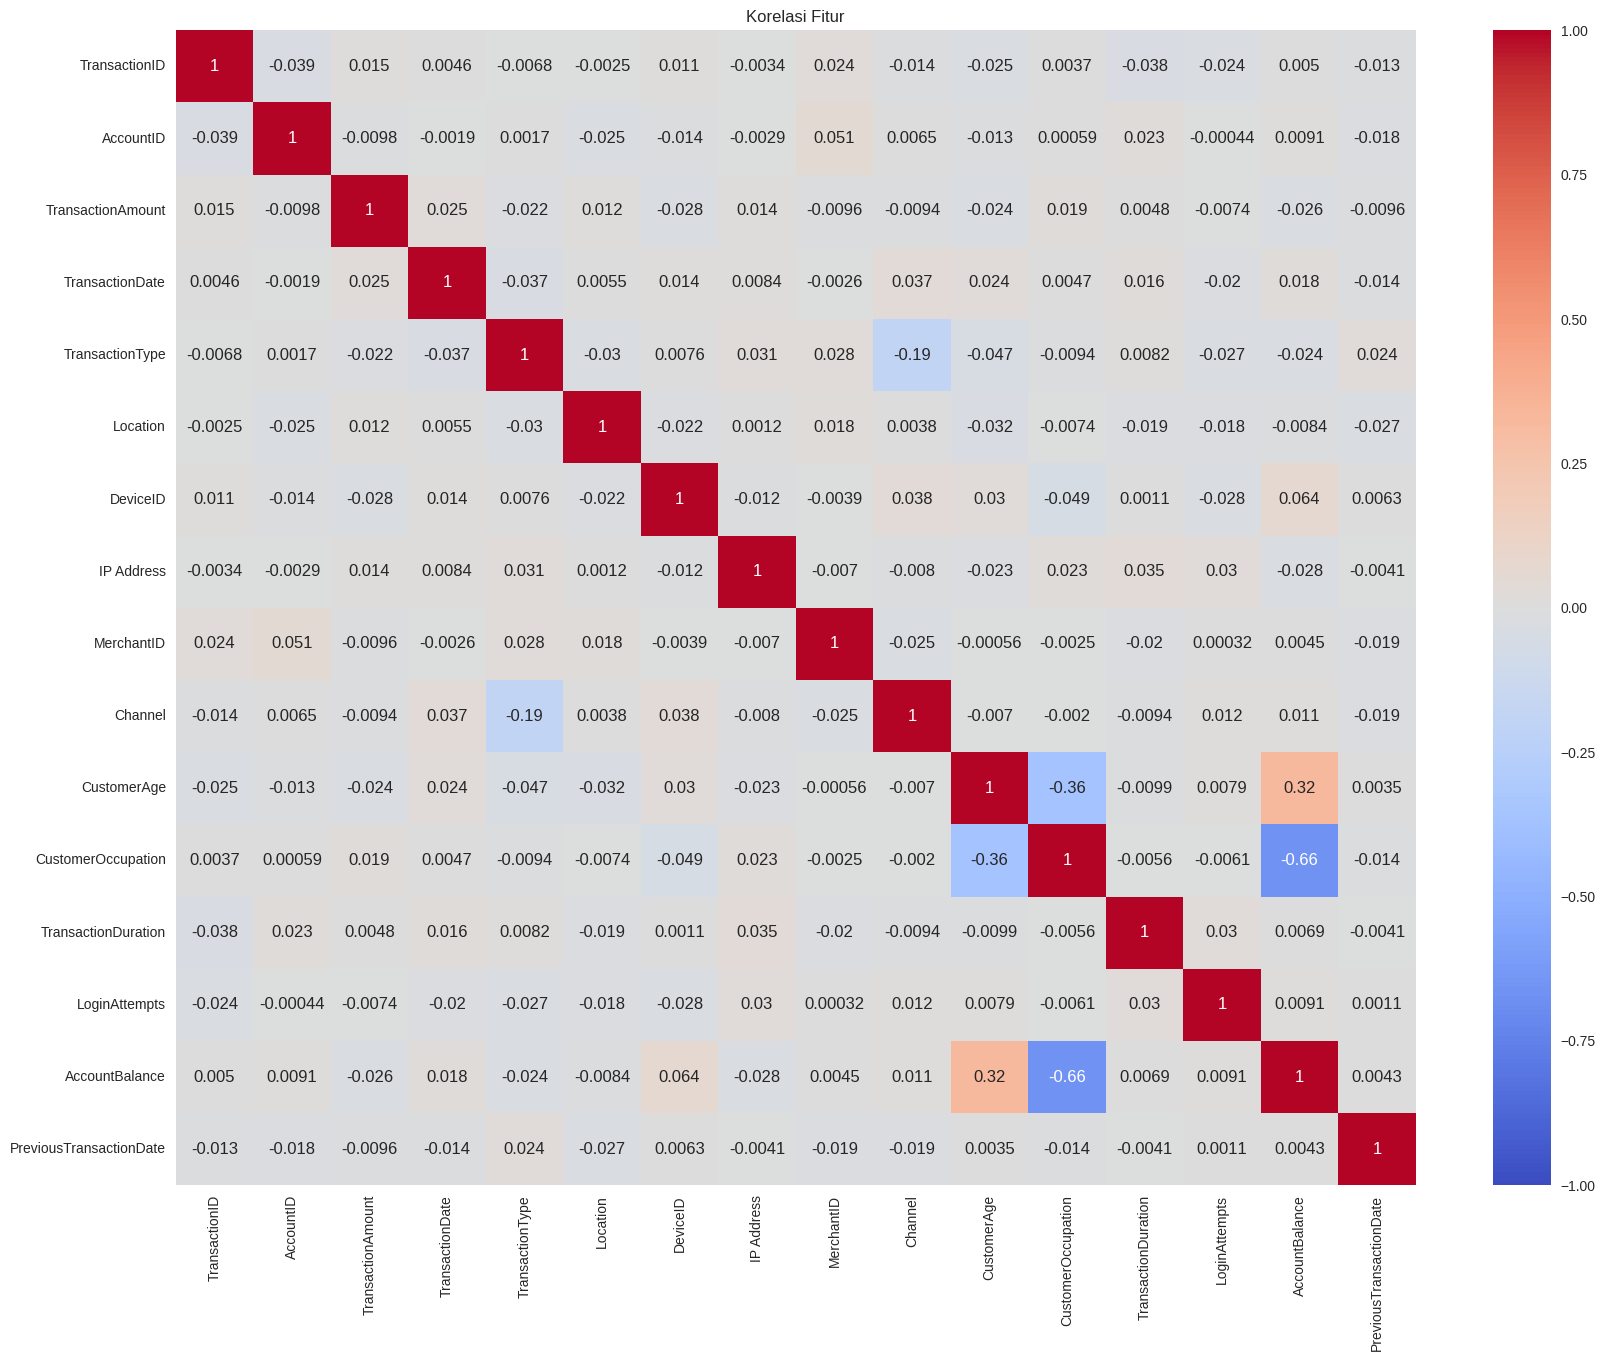

In [ ]:
# Mengelompokan fitur kategori untuk di encoding
kolom_kategori = df.select_dtypes(include=['object']).columns

# Melakukan encoding agar fitur kategori dapat terbaca
df_one_hot = pd.get_dummies(df, columns=kolom_kategori)
le = LabelEncoder()
df_encoding = pd.DataFrame(df)
for col in kolom_kategori:
    df_encoding[col] = le.fit_transform(df_encoding[col])


# Menampilkan korelasi antar fitur (Opsional Skilled 1)
plt.figure(figsize=(20, 15))
korelasi_fitur = df_encoding.corr()
sns.heatmap(korelasi_fitur, annot=True, cmap='coolwarm', vmin= -1, vmax= 1)
plt.title('Korelasi Fitur')
plt.show()

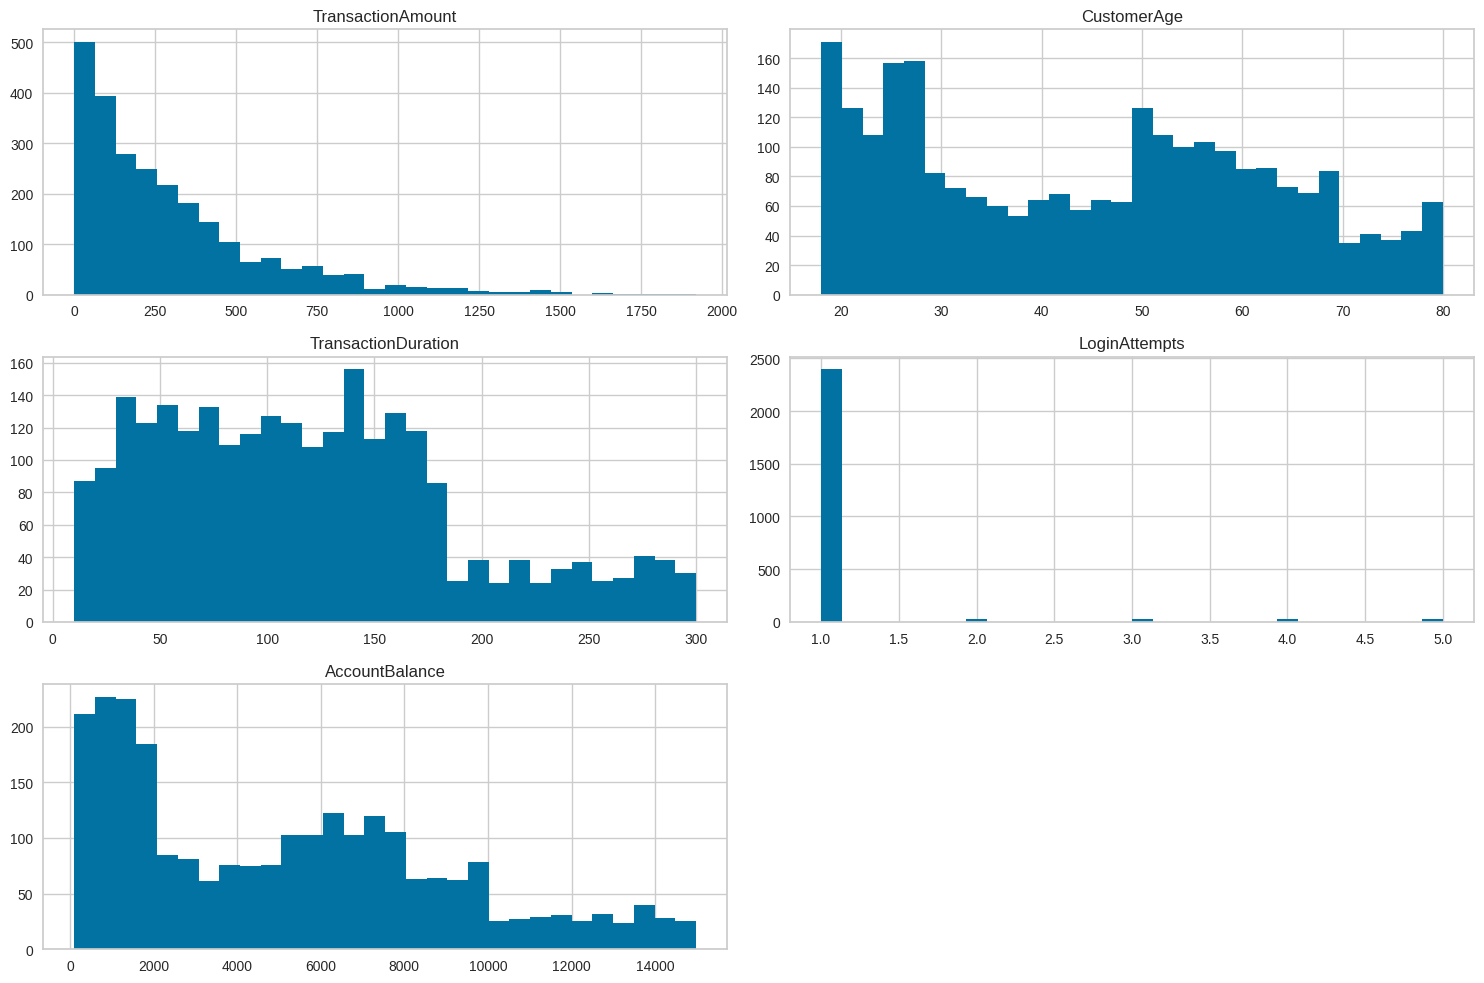

In [ ]:
# Menampilkan histogram untuk semua kolom numerik
kolom_numerik = df.select_dtypes(include=[np.number]).columns.tolist()
df[kolom_numerik].hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

(Opsional) Memuat Dataset dan Melakukan Exploratory Data Analysis (EDA) [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

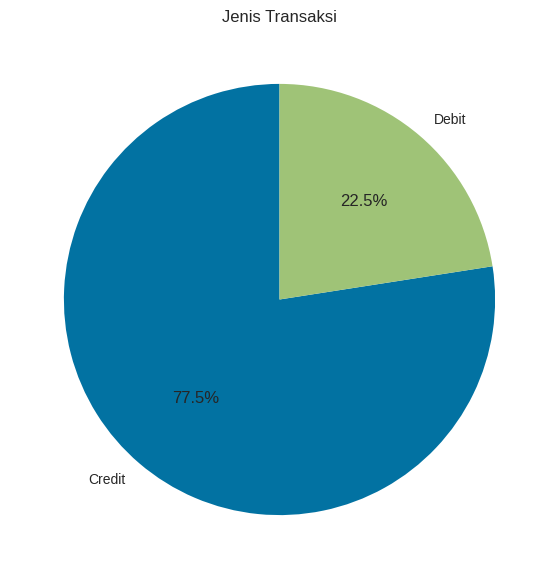

In [ ]:
# Visualisasi yang lebih informatif (Opsional Advanced 1)

# Rata rata tipe transaksi
plt.figure(figsize=(7, 7))
plt.pie(df['TransactionType'].value_counts(), labels=['Credit', 'Debit'], autopct='%1.1f%%', startangle=90)
plt.title('Jenis Transaksi')
plt.show()

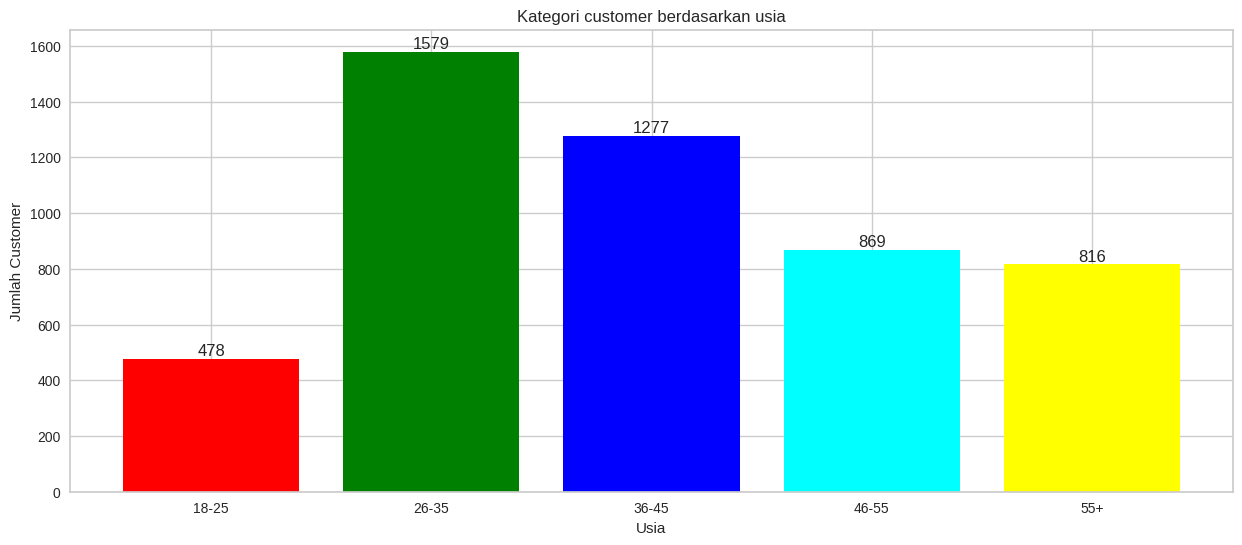

In [ ]:
# Mengelompokan usia cutomer ke dalam kategori dan menghitung jumlah customer
age18_25 = df.CustomerAge[(df.CustomerAge >= 18) & (df.CustomerAge <= 25)]
age26_35 = df.CustomerAge[(df.CustomerAge >= 26) & (df.CustomerAge >= 35)]
age36_45 = df.CustomerAge[(df.CustomerAge >= 36) & (df.CustomerAge >= 45)]
age46_55 = df.CustomerAge[(df.CustomerAge >= 46) & (df.CustomerAge >= 55)]
age55above = df.CustomerAge[(df.CustomerAge >= 56)]

# Menyusun data untuk ploting
x = ['18-25', '26-35', '36-45', '46-55', '55+']
y = [len(age18_25.values), len(age26_35.values), len(age36_45.values), len(age46_55.values), len(age55above.values)]

# Buat bar Chart untuk distribusi cutomer
plt.figure(figsize=(15, 6))
plt.bar(x, y, color=['red', 'green', 'blue', 'cyan', 'yellow'])
plt.title('Kategori customer berdasarkan usia')
plt.xlabel('Usia')
plt.ylabel('Jumlah Customer')

# menambahkan label jumlah cutomer diatas setiap bar
for i in range(len(x)):
    plt.text(i, y[i], y[i], ha='center', va='bottom')

plt.show()


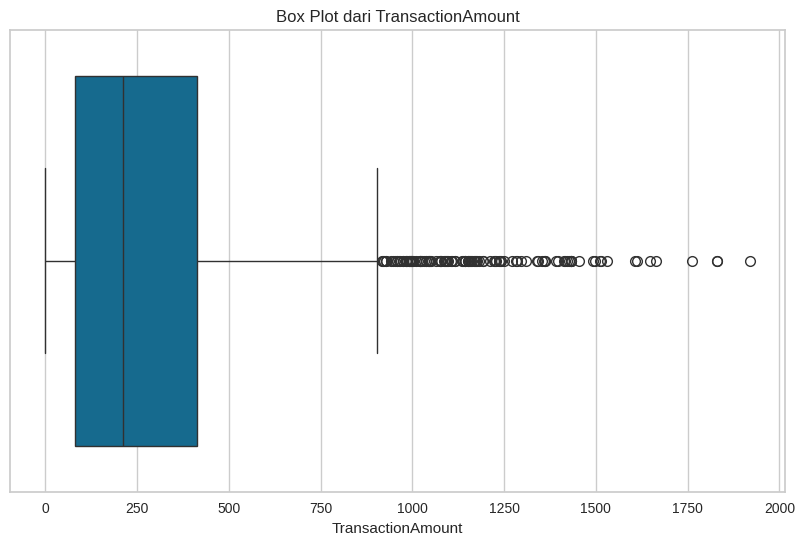

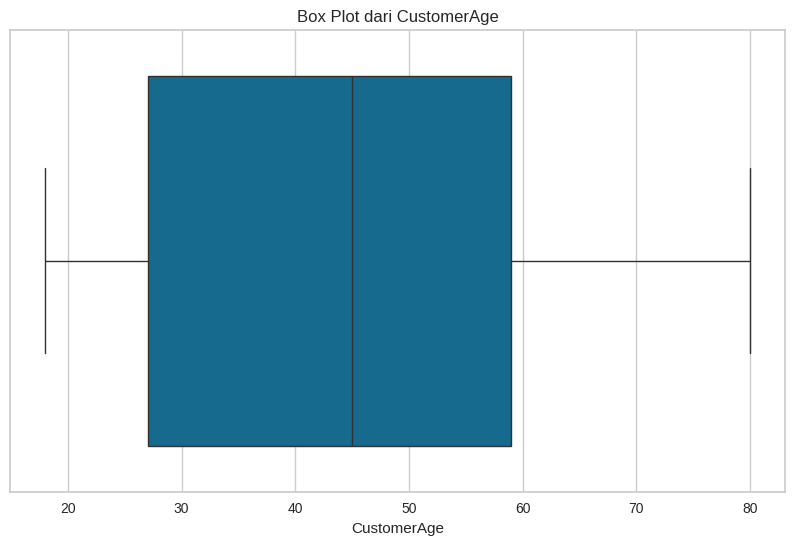

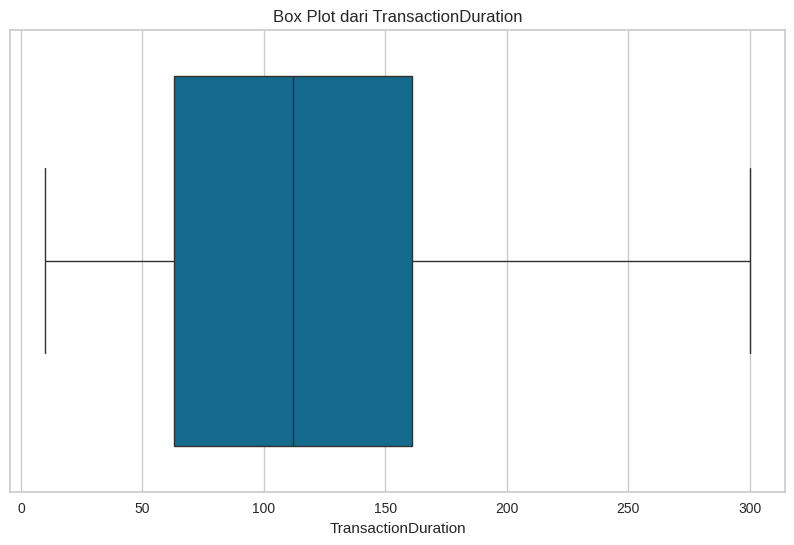

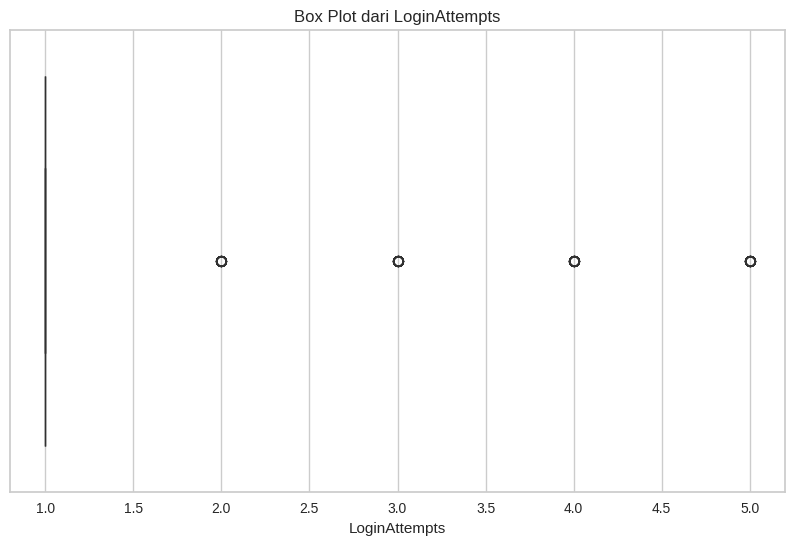

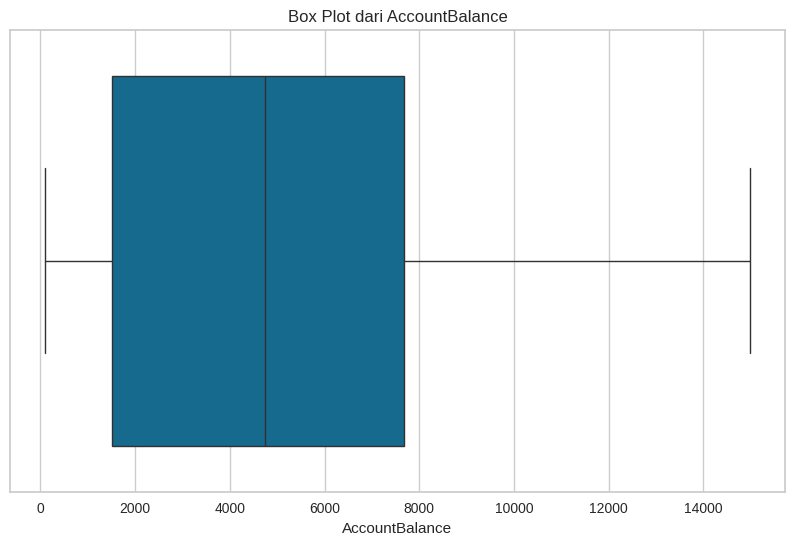

In [ ]:
# Deteksi Outlier Menggunakan Boxplot
for feature in kolom_numerik:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=df[feature])
    plt.title(f'Box Plot dari {feature}')
    plt.show()

# **3. Pembersihan dan Pra Pemrosesan Data**

Pada tahap ini, Anda akan melakukan **Pembersihan Dataset** untuk menjadikan dataset mudah diintepretasi dan bisa dilatih. Hal-hal yang wajib kamu lakukan yaitu:

1. **Mengecek dataset** menggunakan isnull().sum() dan duplicated().sum().
2. Melakukan feature scaling menggunakan `MinMaxScaler()` atau `StandardScalar()` untuk fitur numerik.
3. Melakukan feature encoding menggunakan `LabelEncoder()` untuk fitur kategorikal.
4. Melakukan drop pada kolom id.
5. **Ketentuan Cell Code**
   - Pastikan **setiap pemeriksaan tersebut** memiliki **output pada cell-nya**. Jika tidak **submission langsung ditolak**


In [ ]:
# Mengecek dataset menggunakan isnull().sum()
df.isnull().sum()

,0
TransactionID,29
AccountID,21
TransactionAmount,26
TransactionDate,28
TransactionType,30
Location,30
DeviceID,30
IP Address,20
MerchantID,23
Channel,27


In [ ]:
# Mengecek dataset menggunakan duplicated().sum()
df.duplicated().sum()

np.int64(21)

In [ ]:
# Melakukan feature scaling menggunakan MinMaxScaler() atau StandardScalar() untuk fitur numerik.
fitur_numerik = df.select_dtypes(include=[np.number]).columns.tolist()
scaler = StandardScaler()
df[fitur_numerik] = scaler.fit_transform(df[fitur_numerik])
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,-0.970546,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,1.419862,Doctor,-0.548393,-0.204629,-0.000315,2024-11-04 08:08:08
1,TX000002,AC00455,0.268963,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,1.307715,Doctor,0.307960,-0.204629,2.218381,2024-11-04 08:09:35
2,TX000003,AC00019,-0.586526,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,-1.439874,Student,-0.905207,-0.204629,-1.024091,2024-11-04 08:07:04
3,TX000004,AC00070,-0.387294,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,-1.047361,Student,-1.347656,-0.204629,0.886694,2024-11-04 08:09:06
4,TX000005,AC00411,-0.972736,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,NaN,Student,1.121495,-0.204629,0.594263,2024-11-04 08:06:39


In [ ]:
# Melakukan drop pada kolom yang memiliki keterangan id dan IP Address
df = df.drop(columns=['TransactionID', 'AccountID', 'DeviceID', 'IP Address', 'MerchantID'], axis=1)


In [ ]:
# Mengumpulkan semua fitur kategorikal
fitur_kategori = df.select_dtypes(include=['object']).columns.tolist()
# Melakukan feature encoding menggunakan LabelEncoder() untuk fitur kategorikal.
encoders = {}
df = pd.DataFrame(df)
for col in fitur_kategori:
    encoder = LabelEncoder()
    df[col] = encoder.fit_transform(df[col])
    encoders[col] = encoder
# Pastikan kamu menggunakan function head setelah melalukan encoding.
df.head()

,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,-0.970546,680,1,36,0,1.419862,0,-0.548393,-0.204629,-0.000315,105
1,0.268963,1178,1,15,0,1.307715,0,0.307960,-0.204629,2.218381,192
2,-0.586526,1262,1,23,2,-1.439874,3,-0.905207,-0.204629,-1.024091,41
3,-0.387294,818,1,33,2,-1.047361,3,-1.347656,-0.204629,0.886694,163
4,-0.972736,1939,0,1,2,NaN,3,1.121495,-0.204629,0.594263,16


In [ ]:
# Last checking gunakan columns.tolist() untuk checking seluruh fitur yang ada.
# Perbaiki kode di bawah ini tanpa menambahkan atau mengurangi cell code ini.
df.columns.tolist()

['TransactionAmount',
 'TransactionDate',
 'TransactionType',
 'Location',
 'Channel',
 'CustomerAge',
 'CustomerOccupation',
 'TransactionDuration',
 'LoginAttempts',
 'AccountBalance',
 'PreviousTransactionDate']

(Opsional) Pembersihan dan Pra Pemrosesan Data [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

In [ ]:
# Menangani data yang hilang (bisa menggunakan dropna() atau metode imputasi fillna()).
df.dropna(inplace=True)

In [ ]:
# Menghapus data duplikat menggunakan drop_duplicates().
df.drop_duplicates(inplace=True)

(Opsional) Pembersihan dan Pra Pemrosesan Data [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

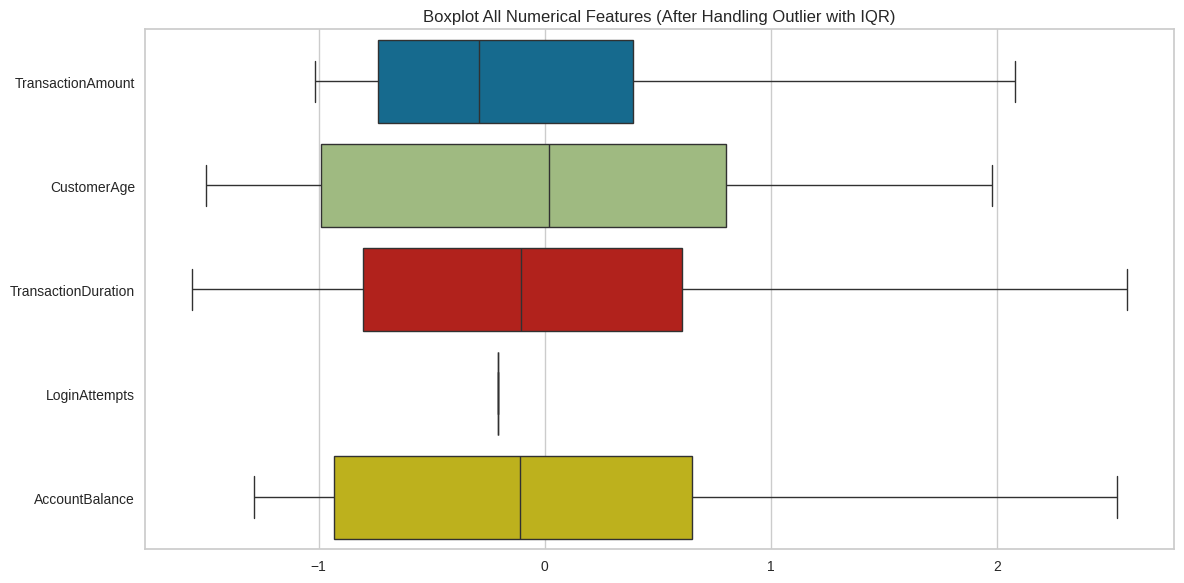

In [ ]:
# Mengisi nilai outlier dengan median
# Identifikasi outlier menggunakan IQR
for col in df[fitur_numerik]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Ganti outlier dengan median
    df[col] = df[col].clip(lower=lower, upper=upper)

plt.figure(figsize=(12, 6))
sns.boxplot(data=df[fitur_numerik], orient="h")
plt.title("Boxplot All Numerical Features (After Handling Outlier with IQR)")
plt.tight_layout()
plt.show()


In [ ]:
# Melakukan binning data berdasarkan kondisi rentang nilai pada fitur numerik,
# lakukan pada satu sampai dua fitur numerik.
# Silahkan lakukan encode hasil binning tersebut menggunakan LabelEncoder.
# Pastikan kamu mengerjakan tahapan ini pada satu cell.

df["Kategori_Transaksi"] = pd.qcut(
    df["TransactionAmount"], q=3,
    labels=['kecil', 'sedang', 'tinggi']
)

age_raw = salinan_df_asli["CustomerAge"].copy()
age_raw = age_raw.fillna(age_raw.median())
age_raw = age_raw.clip(lower=0, upper=100)

df["Kategori_Umur"] = pd.cut(
    age_raw,
    bins=[0,25,45,100],
    labels=['muda', 'dewasa', 'lansia'],
    include_lowest=True, right=True
)

le_trs = LabelEncoder()
le_umr = LabelEncoder()
df["bin_Kategori_Transaksi"] = le_trs.fit_transform(df["Kategori_Transaksi"])
df["bin_Kategori_Umur"]    = le_umr.fit_transform(df["Kategori_Umur"])

display(df[["TransactionAmount","Kategori_Transaksi","bin_Kategori_Transaksi",
                      "CustomerAge","Kategori_Umur","bin_Kategori_Umur"]])

drop_bin_str = ["KategoriTransaksi","Kategori_Umur"]
df_processed = df.drop(columns=[c for c in drop_bin_str if c in df.columns]).copy()

,TransactionAmount,Kategori_Transaksi,bin_Kategori_Transaksi,CustomerAge,Kategori_Umur,bin_Kategori_Umur
0,-0.970546,kecil,0,1.419862,lansia,1
1,0.268963,tinggi,2,1.307715,lansia,1
2,-0.586526,sedang,1,-1.439874,muda,2
3,-0.387294,sedang,1,-1.047361,dewasa,0
5,-0.703375,kecil,0,-1.495947,muda,2
...,...,...,...,...,...,...
2510,-0.382263,sedang,1,-1.215581,muda,2
2511,-0.186796,sedang,1,-1.159507,muda,2
2523,-0.977083,kecil,0,1.756301,lansia,1
2524,-0.224308,sedang,1,-0.430555,dewasa,0


# **4. Membangun Model Clustering**
Pada tahap ini, Anda membangun model clustering dengan memilih algoritma yang sesuai untuk mengelompokkan data berdasarkan kesamaan.
1. Pastikan Anda menggunakan dataframe yang sudah melalui processing sesuai dengan levelnya (Basic, Skilled, Advanced)
2. Melakukan visualisasi Elbow Method untuk menentukan jumlah cluster terbaik menggunakan `KElbowVisualizer()`.
3. Menggunakan algoritma K-Means Clustering dengan `sklearn.cluster.KMeans()`.
4. Jalankan cell code `joblib.dump(model_kmeans, "model_clustering.h5")` untuk menyimpan model yang sudah dibuat.

In [ ]:
# Gunakan describe untuk memastikan proses clustering menggunakan dataset hasil preprocessing
# Lengkapi kode ini dengan mengubah nama DataFrame yang akan dilatih.
# Kode harus digunakan dan dilarang menambahkan syntax lainnya pada cell ini.
df.describe()

,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,bin_Kategori_Transaksi,bin_Kategori_Umur
count,2398.000000,2398.000000,2398.000000,2398.000000,2398.000000,2398.000000,2398.000000,2398.000000,2.398000e+03,2398.000000,2398.000000,2398.000000,2398.000000
mean,-0.045635,1256.404921,0.788574,21.383653,1.013344,-0.003388,1.532110,0.000832,-2.046294e-01,-0.006050,180.984987,1.000417,0.875313
std,0.856137,726.716182,0.437979,12.417622,0.831075,1.000136,1.153802,1.003159,9.883046e-15,1.001030,103.757245,0.816752,0.700354
min,-1.017881,0.000000,0.000000,0.000000,0.000000,-1.495947,0.000000,-1.561745,-2.046294e-01,-1.286100,0.000000,0.000000,0.000000
25%,-0.737943,626.250000,1.000000,11.000000,0.000000,-0.991288,0.000000,-0.805299,-2.046294e-01,-0.929992,92.000000,0.000000,0.000000
50%,-0.290005,1254.500000,1.000000,21.000000,1.000000,0.018031,2.000000,-0.105944,-2.046294e-01,-0.110335,181.000000,1.000000,1.000000
75%,0.389115,1884.750000,1.000000,32.000000,2.000000,0.803056,3.000000,0.607683,-2.046294e-01,0.652406,271.750000,2.000000,1.000000
max,2.079702,2485.000000,2.000000,43.000000,3.000000,1.980594,4.000000,2.577295,-2.046294e-01,2.531190,360.000000,2.000000,2.000000


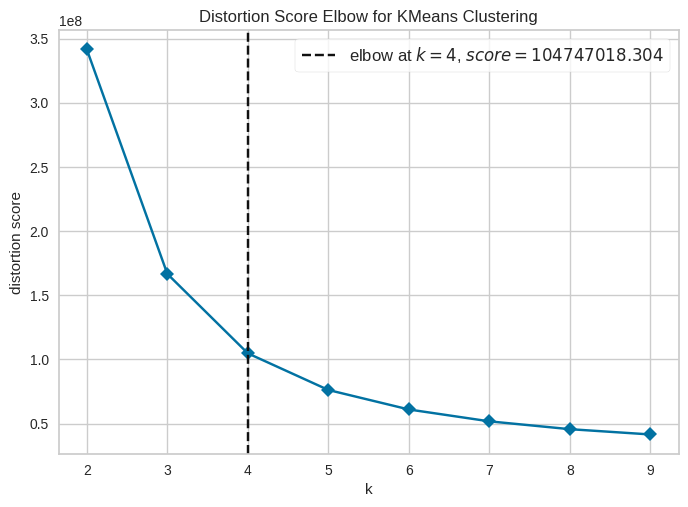

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
# Melakukan visualisasi Elbow Method menggunakan KElbowVisualizer()
X = df.select_dtypes(include=[np.number])
kmeans = KMeans(random_state=42, n_init='auto')
visualisasi = KElbowVisualizer(kmeans, k=(2,10), timings=False)
visualisasi.fit(X)
visualisasi.show()

In [ ]:
# Menggunakan algoritma K-Means Clustering
X = df.select_dtypes(include='number')
k = 4
kmeans = KMeans(n_clusters= k, random_state=42, n_init='auto')
kmeans.fit(X)

# Mendapatkan label cluster
labels = kmeans.labels_

print(f'Jumlah Cluster (k) : {k}')
print(f'Inertia : {kmeans.inertia_:.2f}')

Jumlah Cluster (k) : 4
Inertia : 104747750.66


Jalankan cell code ini untuk menyimpan model kamu.

In [ ]:
# Menyimpan model menggunakan joblib
# import joblib
joblib.dump(df, "model_clustering.h5")

['model_clustering.h5']

(Opsional) Membangun Model Clustering [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

In [ ]:
# Menghitung dan menampilkan nilai Silhouette Score.
sil_score = silhouette_score(X, labels, metric='euclidean')

print(f'Nilai silhoutte score : {sil_score:.4f}')

sil_score_cluster = silhouette_samples(X, labels)

df_sil = pd.DataFrame({"Cluster": labels, "Silhouette": sil_score_cluster})
cluster_scores = df_sil.groupby("Cluster")["Silhouette"].mean()

print("\nSilhouette score per cluster:")
print(cluster_scores)

Nilai silhoutte score : 0.4995

Silhouette score per cluster:
Cluster
0    0.559626
1    0.557417
2    0.438199
3    0.443038
Name: Silhouette, dtype: float64


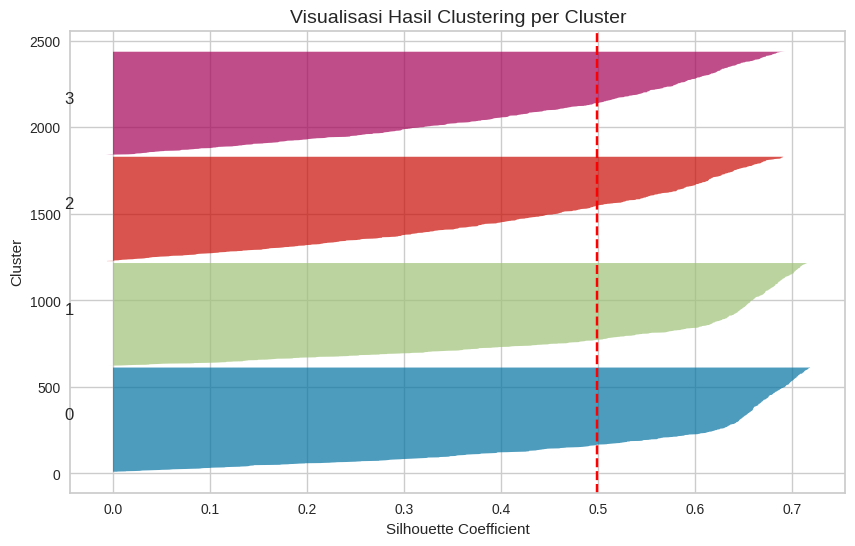

In [ ]:
# Membuat visualisasi hasil clustering

nilai_silhoutte = silhouette_samples(X, labels)

y_lower = 10
plt.figure(figsize=(10, 6))
for i in range(k):
    nilai_silhoutte_percluscter = nilai_silhoutte[labels == i]
    nilai_silhoutte_percluscter.sort()
    size_cluster_i = nilai_silhoutte_percluscter.shape[0]
    y_upper = y_lower + size_cluster_i

    plt.fill_betweenx(
        np.arange(y_lower, y_upper),
        0, nilai_silhoutte_percluscter,
        alpha=0.7
    )
    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

plt.axvline(x=sil_score, color="red", linestyle="--")
plt.title("Visualisasi Hasil Clustering per Cluster", fontsize=14)
plt.xlabel("Silhouette Coefficient")
plt.ylabel("Cluster")
plt.show()

(Opsional) Membangun Model Clustering [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

In [ ]:
# Membangun model menggunakan PCA.
pca =PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
# Menyimpan data PCA sebagai Dataframe dengan nama PCA_numbers
PCA_numbers = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2'])
# Pastikan kamu membangun model Kmeans baru dengan data yang sudah dimodifikasi melalui PCA.
kmeans_pca= KMeans(n_clusters=k, random_state=42)
kmeans_pca.fit(PCA_numbers)

KMeans(n_clusters=4, random_state=42)

In [ ]:
# Simpan model PCA sebagai perbandingan dengan menjalankan cell code ini joblib.dump(model,"PCA_model_clustering.h5")
# Pastikan yang disimpan model yang sudah melalui .fit berdasarkan dataset yang sudah dilakukan PCA
joblib.dump(kmeans_pca, "PCA_model_clustering.h5")

['PCA_model_clustering.h5']

# **5. Interpretasi Cluster**

## **a. Interpretasi Hasil Clustering**
1. **Contoh Interpretasi:**
- **Cluster 1: (Nasabah Bertransaksi dan Pendapatan Besar)**:
  - **Rata-rata (mean) Annual Income:** 0.953 (48,260)
  - **Rata-rata (mean) Spending Score:** 0.8 (56.48)
  - **Analisis:** Cluster ini mencakup pelanggan dengan pendapatan tahunan tinggi dan tingkat pengeluaran yang cukup tinggi. Pelanggan dalam cluster ini cenderung memiliki daya beli yang tinggi dan mereka lebih cenderung untuk membelanjakan sebagian besar pendapatan mereka. Sehingga rekomendasi pada kelompok nasabah ini adalah dengan menawarkan produk-produk investasi atau perbankan yang berkualitas tinggi.


In [ ]:
# Menampilkan analisis deskriptif minimal mean, min dan max untuk fitur numerik.
# Silakan menambahkan fungsi agregasi lainnya untuk experience lebih baik.
# pastikan output menghasilkan agregasi dan groupby bersamaan dengan mean, min, dan max.

# Menambahkan label cluster ke dataframe
df["Cluster"] = kmeans_pca.labels_

fitur_numerik2 = df.drop(columns="Cluster").select_dtypes(include="number")
print('Analisis Deskriptif Fitur Numerik')
kolom_numerik = [c for c in df.select_dtypes(include=np.number).columns if c != "Target"]

# melooping setiap cluster dan menampilkan ringkasan deskriptif
for c in sorted(df["Cluster"].unique()):
    print(f"\n Cluster : {c} ")
    cluster_data = fitur_numerik2[df["Cluster"] == c]

    summary = cluster_data.agg(["min", "max", "mean", "median"]).T
    summary.columns = ["Min", "Max", "Mean", "Median"]

    display(summary)

kuartil = df[kolom_numerik].quantile([0.25, 0.5, 0.75]).T
kuartil.columns = ["Q1", "Q2", "Q3"]
mean_global = df[kolom_numerik].mean().rename("mean_global")
stats_kuartil = pd.concat([kuartil, mean_global], axis=1)
display(stats_kuartil)

Analisis Deskriptif Fitur Numerik

 Cluster : 0 


,Min,Max,Mean,Median
TransactionAmount,-1.017881,2.079702,-0.063183,-0.294232
TransactionDate,1876.000000,2485.000000,2196.220033,2199.000000
TransactionType,0.000000,2.000000,0.773399,1.000000
Location,0.000000,43.000000,21.279146,21.000000
Channel,0.000000,3.000000,1.064039,1.000000
CustomerAge,-1.495947,1.980594,0.009468,0.074104
CustomerOccupation,0.000000,4.000000,1.510673,1.000000
TransactionDuration,-1.561745,2.577295,0.024899,-0.134489
LoginAttempts,-0.204629,-0.204629,-0.204629,-0.204629
AccountBalance,-1.274746,2.531190,0.035170,-0.024317



 Cluster : 1 


,Min,Max,Mean,Median
TransactionAmount,-1.015827,2.079702,-0.048985,-0.273970
TransactionDate,0.000000,617.000000,308.718644,309.500000
TransactionType,0.000000,2.000000,0.810169,1.000000
Location,0.000000,43.000000,21.500000,22.000000
Channel,0.000000,3.000000,0.972881,1.000000
CustomerAge,-1.495947,1.980594,-0.068930,-0.206262
CustomerOccupation,0.000000,4.000000,1.498305,1.000000
TransactionDuration,-1.561745,2.563023,-0.039565,-0.155898
LoginAttempts,-0.204629,-0.204629,-0.204629,-0.204629
AccountBalance,-1.285856,2.522155,-0.024486,-0.124599



 Cluster : 2 


,Min,Max,Mean,Median
TransactionAmount,-1.017676,2.079702,0.016185,-0.288311
TransactionDate,1242.000000,1875.000000,1558.986733,1562.000000
TransactionType,0.000000,2.000000,0.786070,1.000000
Location,0.000000,43.000000,21.462687,21.000000
Channel,0.000000,3.000000,1.001658,1.000000
CustomerAge,-1.495947,1.980594,0.025935,0.074104
CustomerOccupation,0.000000,4.000000,1.580431,2.000000
TransactionDuration,-1.561745,2.563023,0.021799,-0.063127
LoginAttempts,-0.204629,-0.204629,-0.204629,-0.204629
AccountBalance,-1.286100,2.520287,-0.028861,-0.153104



 Cluster : 3 


,Min,Max,Mean,Median
TransactionAmount,-1.013945,2.079702,-0.086936,-0.337477
TransactionDate,615.000000,1240.000000,928.100671,928.500000
TransactionType,0.000000,2.000000,0.785235,1.000000
Location,0.000000,43.000000,21.295302,21.000000
Channel,0.000000,3.000000,1.013423,1.000000
CustomerAge,-1.495947,1.980594,0.018689,0.074104
CustomerOccupation,0.000000,4.000000,1.538591,2.000000
TransactionDuration,-1.561745,2.548750,-0.004983,-0.055990
LoginAttempts,-0.204629,-0.204629,-0.204629,-0.204629
AccountBalance,-1.284661,2.512436,-0.006839,-0.133839


,Q1,Q2,Q3,mean_global
TransactionAmount,-0.737943,-0.290005,0.389115,-0.045635
TransactionDate,626.250000,1254.500000,1884.750000,1256.404921
TransactionType,1.000000,1.000000,1.000000,0.788574
Location,11.000000,21.000000,32.000000,21.383653
Channel,0.000000,1.000000,2.000000,1.013344
CustomerAge,-0.991288,0.018031,0.803056,-0.003388
CustomerOccupation,0.000000,2.000000,3.000000,1.532110
TransactionDuration,-0.805299,-0.105944,0.607683,0.000832
LoginAttempts,-0.204629,-0.204629,-0.204629,-0.204629
AccountBalance,-0.929992,-0.110335,0.652406,-0.006050


## Menjelaskan karakteristik tiap cluster berdasarkan rentangnya.
1. **Cluster 1: (Label model : Target= 0)**: Nasabah Dewasa dengan Aktivitas Stabil
- TransactionAmount → Min: -1.0179 | Max: 2.0797 | Mean: -0.0632 | Median: -0.2942
- TransactionDate → Min: 1876 | Max: 2485 | Mean: 2196.22 | Median: 2199
- TransactionType → Min: 0 | Max: 2 | Mean: 0.7734 | Median: 1
- Location → Min: 0 | Max: 43 | Mean: 21.279 | Median: 21
- Channel → Min: 0 | Max: 3 | Mean: 1.064 | Median: 1
- CustomerAge → Min: -1.496 | Max: 1.981 | Mean: 0.0095 | Median: 0.0741
- CustomerOccupation → Min: 0 | Max: 4 | Mean: 1.5107 | Median: 1
- TransactionDuration → Min: -1.5617 | Max: 2.5773 | Mean: 0.0249 | Median: -0.1345
- LoginAttempts → -0.2046 (konstan)
- AccountBalance → Min: -1.2747 | Max: 2.5312 | Mean: 0.0352 | Median: -0.0243
- PreviousTransactionDate → Min: 0 | Max: 360 | Mean: 181.655 | Median: 181
- bin_Kategori_Transaksi → Min: 0 | Max: 2 | Mean: 0.9901 | Median: 1
- bin_Kategori_Umur → Min: 0 | Max: 2 | Mean: 0.8818 | Median: 1
- Analisis: Cluster ini mencakup nasabah dewasa menengah dengan transaksi nilai kecil hingga sedang. Rentang nilai transaksi menunjukkan distribusi yang beragam (min -1.0179, max 2.0797), durasi transaksi bervariasi. Lokasi dan channel transaksi tersebar, dan jarak antar transaksi sebelumnya cukup stabil (~181 hari). Target=0 menunjukkan nasabah normal, dengan pola transaksi rutin dan risiko fraud rendah.
2. **Cluster 2 (label model: Target=1)**: Nasabah Muda dengan Transaksi Awal dan Saldo Rendah
- TransactionAmount → Min: -1.0158 | Max: 2.0797 | Mean: -0.0490 | Median: -0.2740
- TransactionDate → Min: 0 | Max: 617 | Mean: 308.719 | Median: 309.5
- TransactionType → Min: 0 | Max: 2 | Mean: 0.8102 | Median: 1
- Location → Min: 0 | Max: 43 | Mean: 21.5 | Median: 22
- Channel → Min: 0 | Max: 3 | Mean: 0.9729 | Median: 1
- CustomerAge → Min: -1.4959 | Max: 1.9806 | Mean: -0.0689 | Median: -0.2063
- CustomerOccupation → Min: 0 | Max: 4 | Mean: 1.4983 | Median: 1
- TransactionDuration → Min: -1.5617 | Max: 2.5630 | Mean: -0.0396 | Median: -0.1559
- LoginAttempts → -0.2046 (konstan)
- AccountBalance → Min: -1.2859 | Max: 2.5222 | Mean: -0.0245 | Median: -0.1246
- PreviousTransactionDate → Min: 0 | Max: 360 | Mean: 188.817 | Median: 195
- bin_Kategori_Transaksi → Min: 0 | Max: 2 | Mean: 1.0017 | Median: 1
- bin_Kategori_Umur → Min: 0 | Max: 2 | Mean: 0.8610 | Median: 1
- Analisis: Cluster ini mewakili nasabah muda hingga dewasa awal, dengan transaksi kecil (median -0.274) dan saldo cenderung rendah. Durasi transaksi pendek dan sebagian besar menggunakan channel 1. Target=1 → fraud tipe 1, menunjukkan risiko percobaan penipuan atau transaksi awal yang lebih tinggi dibanding cluster normal.
3. **Cluster 3 (label model: Target=2)**: Nasabah Dewasa Menengah dengan Transaksi Lebih Tinggi
- TransactionAmount → Min: -1.0177 | Max: 2.0797 | Mean: 0.0162 | Median: -0.2883
- TransactionDate → Min: 1242 | Max: 1875 | Mean: 1558.987 | Median: 1562
- TransactionType → Min: 0 | Max: 2 | Mean: 0.7861 | Median: 1
- Location → Min: 0 | Max: 43 | Mean: 21.4627 | Median: 21
- Channel → Min: 0 | Max: 3 | Mean: 1.0017 | Median: 1
- CustomerAge → Min: -1.4959 | Max: 1.9806 | Mean: 0.0259 | Median: 0.0741
- CustomerOccupation → Min: 0 | Max: 4 | Mean: 1.5804 | Median: 2
- TransactionDuration → Min: -1.5617 | Max: 2.5630 | Mean: 0.0218 | Median: -0.0631
- LoginAttempts → -0.2046 (konstan)
- AccountBalance → Min: -1.2861 | Max: 2.5203 | Mean: -0.0289 | Median: -0.1531
- PreviousTransactionDate → Min: 0 | Max: 360 | Mean: 180.791 | Median: 183
- bin_Kategori_Transaksi → Min: 0 | Max: 2 | Mean: 1.0464 | Median: 1
- bin_Kategori_Umur → Min: 0 | Max: 2 | Mean: 0.8690 | Median: 1
- Analisis: Cluster ini mencakup nasabah dewasa menengah dengan transaksi nominal sedikit lebih tinggi. Median transaksi -0.2883 menunjukkan sebagian besar transaksi di bawah rata-rata global, durasi transaksi bervariasi. Target=2 → fraud tipe 2, pola transaksi lebih kompleks dibanding cluster normal.
4. **Cluster 4 (Target=3)**: Nasabah Dewasa dengan Aktivitas Menengah dan Transaksi Kecil
- TransactionAmount → Min: -1.0139 | Max: 2.0797 | Mean: -0.0869 | Median: -0.3375
- TransactionDate → Min: 615 | Max: 1240 | Mean: 928.101 | Median: 928.5
- TransactionType → Min: 0 | Max: 2 | Mean: 0.7852 | Median: 1
- Location → Min: 0 | Max: 43 | Mean: 21.2953 | Median: 21=
- Channel → Min: 0 | Max: 3 | Mean: 1.0134 | Median: 1
- CustomerAge → Min: -1.4959 | Max: 1.9806 | Mean: 0.0187 | Median: 0.0741
- CustomerOccupation → Min: 0 | Max: 4 | Mean: 1.5386 | Median: 2
- TransactionDuration → Min: -1.5617 | Max: 2.5488 | Mean: -0.00498 | Median: -0.0560
- LoginAttempts → -0.2046 (konstan)
- AccountBalance → Min: -1.2847 | Max: 2.5124 | Mean: -0.0068 | Median: -0.1338
- PreviousTransactionDate → Min: 0 | Max: 360 | Mean: 172.743 | Median: 171.5
- bin_Kategori_Transaksi → Min: 0 | Max: 2 | Mean: 0.9631 | Median: 1
- bin_Kategori_Umur → Min: 0 | Max: 2 | Mean: 0.8893 | Median: 1
- Analisis : Cluster ini mewakili nasabah dewasa menengah dengan transaksi kecil (median -0.3375) dan variasi kategori transaksi terbatas. Aktivitas menengah, channel sebagian besar 1, lokasi tersebar. Target=3 → fraud tipe 3, menunjukkan pola transaksi berulang meski nominal kecil.

# **6. Mengeksport Data**

1. Simpan nama kolom hasil clustering dengan nama `Target`.
2. Simpan hasilnya ke dalam file CSV menggunakan function `to_csv()`.

In [ ]:
# Pastikan nama kolom clustering sudah diubah menjadi Target
df.rename(columns={"Cluster": "Target"}, inplace=True)
df.head()


,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,Kategori_Transaksi,Kategori_Umur,bin_Kategori_Transaksi,bin_Kategori_Umur,Target
0,-0.970546,680,1,36,0,1.419862,0,-0.548393,-0.204629,-0.000315,105,kecil,lansia,0,1,3
1,0.268963,1178,1,15,0,1.307715,0,0.307960,-0.204629,2.218381,192,tinggi,lansia,2,1,3
2,-0.586526,1262,1,23,2,-1.439874,3,-0.905207,-0.204629,-1.024091,41,sedang,muda,1,2,2
3,-0.387294,818,1,33,2,-1.047361,3,-1.347656,-0.204629,0.886694,163,sedang,dewasa,1,0,3
5,-0.703375,635,1,28,0,-1.495947,3,0.750409,-0.204629,-1.111505,13,kecil,muda,0,2,3


In [ ]:
# Simpan Data
df.to_csv('data_clustering.csv', index=False)

(Opsional) Interpretasi Hasil Clustering [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

In [ ]:
fitur_numerik

['TransactionAmount',
 'CustomerAge',
 'TransactionDuration',
 'LoginAttempts',
 'AccountBalance']

In [ ]:
# Scaling fitur yang tadi sempat di tambahkan dan belum terscaling

df[fitur_numerik] = scaler.inverse_transform(df[fitur_numerik])
df.head()

,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,Kategori_Transaksi,Kategori_Umur,bin_Kategori_Transaksi,bin_Kategori_Umur,Target
0,14.09,680,1,36,0,70.0,0,81.0,1.0,5112.21,105,kecil,lansia,0,1,3
1,376.24,1178,1,15,0,68.0,0,141.0,1.0,13758.91,192,tinggi,lansia,2,1,3
2,126.29,1262,1,23,2,19.0,3,56.0,1.0,1122.35,41,sedang,muda,1,2,2
3,184.50,818,1,33,2,26.0,3,25.0,1.0,8569.06,163,sedang,dewasa,1,0,3
5,92.15,635,1,28,0,18.0,3,172.0,1.0,781.68,13,kecil,muda,0,2,3


In [ ]:
# inverse dataset yang sudah diencode ke kategori aslinya.
# Lengkapi kode berikut jika ingin menerapkan kriteria ini (silakan hapus simbol pagar pada kode yang akan digunakan.)
df['Kategori_Umur'] = le_umr.inverse_transform(df['bin_Kategori_Umur'].astype(int))
df['Kategori_Transaksi'] = le_trs.inverse_transform(df['bin_Kategori_Transaksi'].astype(int))

kolom_kategori_inverse = ['TransactionType', 'Location', 'Channel', 'CustomerOccupation']
for col in kolom_kategori_inverse:
    if col in encoders:
        encoder = encoders[col]
        df[col] = encoder.inverse_transform(df[col].astype(int))

# tampilkan dataset yang sudah di-inverse
df.head()


,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,Kategori_Transaksi,Kategori_Umur,bin_Kategori_Transaksi,bin_Kategori_Umur,Target
0,14.09,680,Debit,San Diego,ATM,70.0,Doctor,81.0,1.0,5112.21,105,kecil,lansia,0,1,3
1,376.24,1178,Debit,Houston,ATM,68.0,Doctor,141.0,1.0,13758.91,192,tinggi,lansia,2,1,3
2,126.29,1262,Debit,Mesa,Online,19.0,Student,56.0,1.0,1122.35,41,sedang,muda,1,2,2
3,184.50,818,Debit,Raleigh,Online,26.0,Student,25.0,1.0,8569.06,163,sedang,dewasa,1,0,3
5,92.15,635,Debit,Oklahoma City,ATM,18.0,Student,172.0,1.0,781.68,13,kecil,muda,0,2,3


In [ ]:
# Lakukan analisis deskriptif minimal mean, min dan max untuk fitur numerik dan mode untuk kategorikal seperti pada basic tetapi menggunakan data yang sudah diinverse.
# pastikan output menghasilkan agregasi dan groupby bersamaan dengan mean, min, dan max kembali setelah melakukan inverse.
print('Analisis deskriptif fitur numerik berdasarkan cluster :')
fitur_numerik = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
analisis_numerik = df.groupby('Target')[fitur_numerik].agg(['mean', 'min', 'max'])
print(analisis_numerik)
print('Analisis deskriptif fitur kategori berdasarkan cluster :')
fitur_kategori = df.select_dtypes(include=['object']).columns.tolist()
analisis_kategori = df.groupby('Target')[fitur_kategori].agg(lambda x: x.mode()[0])
print(analisis_kategori)

Analisis deskriptif fitur numerik berdasarkan cluster :
       TransactionAmount                 TransactionDate              \
                    mean   min       max            mean   min   max   
Target                                                                 
0             279.196211  0.26  905.2875     2196.220033  1876  2485   
1             283.344462  0.86  905.2875      308.718644     0   617   
2             302.385261  0.32  905.2875     1558.986733  1242  1875   
3             272.256170  1.41  905.2875      928.100671   615  1240   

       CustomerAge             TransactionDuration  ... AccountBalance  \
              mean   min   max                mean  ...            max   
Target                                              ...                  
0        44.847291  18.0  80.0          121.167488  ...       14977.99   
1        43.449153  18.0  80.0          116.650847  ...       14942.78   
2        45.140962  18.0  80.0          120.950249  ...       14935.5

## Menjelaskan karakteristik tiap cluster berdasarkan rentangnya setelah inverse.
1. **Kluster 1:** (Nasabah Engineer Digital dengan Transaksi Kecil)
- **Rata-rata TransactionAmount:** 279.196
- **Rata-rata CustomerAge:** 44.8
- **Rata-rata AccountBalance:** 5090.472
- **Mode CustomerOccupation:** Engineer
- **Mode Channel:** Online
- **Analisis:** Kelompok ini didominasi oleh nasabah yang berprofesi sebagai engineer dengan usia paruh baya. Mereka cenderung melakukan transaksi debit dengan nominal kecil, namun memiliki saldo akun relatif besar dan stabil. Preferensi transaksi online menunjukkan bahwa mereka termasuk kelompok melek digital dengan tingkat adopsi teknologi tinggi.

2. **Kluster 2:** (Nasabah Dokter Tradisional dengan Transaksi Tinggi)
- **Rata-rata TransactionAmount:** 283.34
- **Rata-rata CustomerAge:** 43.4
- **Rata-rata AccountBalance:** 5089.73
- **Mode CustomerOccupation:** Doctor
- **Mode Channel:** Branch
- **Analisis:** Klaster ini didominasi oleh dokter dengan usia paruh baya. Mereka bertransaksi dengan nominal cukup tinggi dan lebih memilih datang ke cabang. Hal ini menandakan kebiasaan perbankan yang lebih konvensional meskipun profesinya mapan.

3. **Kluster 3:** (Nasabah Pensiunan ATM dengan Transaksi Terbesar)
- **Rata-rata TransactionAmount:** 302.39 → terbesar di antara semua cluster
- **Rata-rata CustomerAge:** 45.1
- **Rata-rata AccountBalance:** 5061.97
- **Mode CustomerOccupation:** Retired
- **Mode Channel:** ATM
- **Analisis:** Klaster ini berisi nasabah pensiunan yang masih aktif bertransaksi dengan nominal relatif besar. Mereka lebih nyaman menggunakan ATM ketimbang layanan online atau cabang. Saldo rata-rata mereka lebih rendah dibanding engineer, mungkin karena dana pensiun banyak digunakan untuk kebutuhan rutin.

4. **Kluster 4:** (Nasabah Mahasiswa Non-Tradisional dengan Transaksi Sedang)
- **Rata-rata TransactionAmount:** 272.26
- **Rata-rata CustomerAge:** 45.0
- **Rata-rata AccountBalance:** 5075.48
- **Mode CustomerOccupation:** Student
- **Mode Channel:** Branch
- **Analisis:** Klaster ini cukup unik karena didominasi oleh nasabah berstatus student dengan usia rata-rata 45 tahun (kemungkinan mahasiswa non-tradisional atau pekerja yang masih kuliah). Nilai transaksi mereka sedang, saldo akun terjaga, dan mereka lebih suka bertransaksi langsung di cabang.


(Opsional) Interpretasi Hasil Clustering [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**
1. **Kluster 1:** Nasabah Engineer Digital dengan Transaksi Kecil
- **Profil:** Usia paruh baya (45 th), profesi mayoritas engineer, saldo akun relatif tinggi, nilai transaksi kecil sampai dengan sedang.
- **Perilaku:** Lebih banyak menggunakan channel online, artinya melek digital dan terbiasa dengan teknologi.
- **Interpretasi:** Segmen ini potensial untuk promosi layanan digital banking, mobile banking premium, atau investasi karena mereka punya saldo besar dan literasi teknologi yang baik.

2. **Kluster 2 :** Nasabah Dokter Tradisional dengan Transaksi Tinggi
- **Profil:** Usia paruh baya, mayoritas dokter, nilai transaksi cukup tinggi,  saldo akun stabil.
- **Perilaku:** Lebih memilih datang ke cabang untuk bertransaksi.
- **Interpretasi:** Segmen ini lebih konservatif. Bank bisa mengarahkan mereka ke layanan personal banker, produk kredit konsumtif, atau layanan prioritas di cabang karena mereka menghargai interaksi tatap muka.

3. **Kluster 3:** Nasabah Pensiunan ATM dengan Transaksi Terbesar
- **Profil:** Usia paruh baya–lansia, profesi dominan retired, nilai transaksi paling tinggi, saldo lebih rendah dibanding cluster lain.
- **Perilaku:** Lebih nyaman menggunakan ATM ketimbang online/cabang.
- **Interpretasi:** Segmen ini merepresentasikan pensiunan aktif yang sering mencairkan dana untuk kebutuhan harian. Cocok ditawarkan produk pensiun, asuransi kesehatan, atau tabungan berjangka dengan kemudahan tarik tunai.

4. **Kluster 4:** Nasabah Mahasiswa Non-Tradisional dengan Transaksi Sedang
- **Profil:** Usia rata-rata 45 tahun, berstatus student, nilai transaksi sedang, saldo akun cukup stabil.
- **Perilaku:** Lebih suka bertransaksi di cabang.
- **Interpretasi:** Segmen unik, kemungkinan berisi pekerja paruh baya yang masih kuliah (non-traditional student). Perilakunya konvensional, sehingga cocok ditargetkan dengan layanan edukasi keuangan dan program loyalitas di cabang.

In [ ]:
# Mengintegrasikan kembali data yang telah di-inverse dengan hasil cluster.
df['Target'] = kmeans.labels_

print('DataFrame setelah di integrasi dengan hasil clustering : ')
print(df.head())


DataFrame setelah di integrasi dengan hasil clustering : 
   TransactionAmount  TransactionDate TransactionType       Location Channel  \
0              14.09              680           Debit      San Diego     ATM   
1             376.24             1178           Debit        Houston     ATM   
2             126.29             1262           Debit           Mesa  Online   
3             184.50              818           Debit        Raleigh  Online   
5              92.15              635           Debit  Oklahoma City     ATM   

   CustomerAge CustomerOccupation  TransactionDuration  LoginAttempts  \
0         70.0             Doctor                 81.0            1.0   
1         68.0             Doctor                141.0            1.0   
2         19.0            Student                 56.0            1.0   
3         26.0            Student                 25.0            1.0   
5         18.0            Student                172.0            1.0   

   AccountBalance  Pre

In [ ]:
# Simpan Data
df.to_csv('data_clustering_inverse.csv', index=False)

End of Code.